# Proof of concept: Matrix Wavelet Transforms in 2D with CVXPY
February 16, 2024

We've shown that it is possible to perform the wavelet deconstruction and reconstruction using matrix transformations in 1D.

Now, it is a bit more complicated to perform this in 2D, but we may be able to leverage the fact that the operations for 2D wavelet transforms are essential still in the 1D at a time—across the rows or columns.

We can start by determing if we can do this in numpy with the LL filter only. That is low-horizontal pass along the rows, followed by a low-vertical pass along the columns.

Then, reversed to perform the reconstruction.


In [8]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
import numpy as np
import pywt

In [2]:
# let's start with a 16x16 of a chromatin image

from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

config = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config)
chromatin_model.load_mnase_gene('CLN1', replicate=1)

Loading MNase reads for CLN1...Done.


In [4]:
chromatin_model.create_deconvolution_bins(smoothing=False)

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


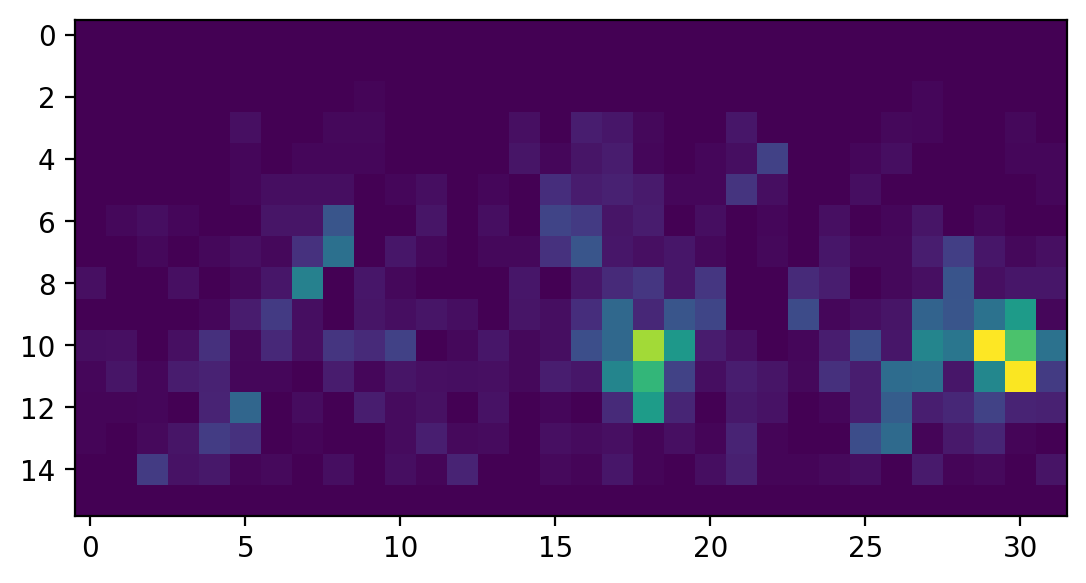

In [55]:
chromatin_model.deconv_hist_unflattened[0].shape
image = chromatin_model.deconv_hist_unflattened[0][:, :32]
plt.imshow(image)

In [12]:
import pywt

wavelet = pywt.Wavelet('bior4.4')
# Obtain filters
dec_lo, dec_hi = wavelet.dec_lo, wavelet.dec_hi
rec_lo, rec_hi = wavelet.rec_lo, wavelet.rec_hi

In [62]:
from src.linalg_wavelets import create_downsample_convolution_matrix, \
    create_upsample_convolution_matrix

# Assume a square image for now
n, m = image.shape[0], image.shape[1]

# Wavelet selection
wavelet = pywt.Wavelet('db1')

# Create matrices that will decompose and downsample
down_lo_horizontal_mat = create_downsample_convolution_matrix(m, dec_lo)
down_lo_vertical_mat = create_downsample_convolution_matrix(n, dec_lo)

down_lo_horizontal_mat.shape, down_lo_vertical_mat.shape


((32, 16), (16, 8))

In [63]:
image.shape

(16, 32)

In [81]:
# Perform the matrix multiplication along the rows of the image
L = np.matmul(image, down_lo_horizontal_mat)

# Transpose the input so we are operating on the columns
# then transpose the result so the image is back to original
# orientation
LL = np.matmul(L.T, down_lo_vertical_mat).T

LL.shape

(8, 16)

In [84]:
# Reconstruction matrices
up_lo_horizontal_mat = create_upsample_convolution_matrix(m, rec_lo)
up_lo_vertical_mat = create_upsample_convolution_matrix(n, rec_lo)

# Upsample along the columns, then upsample along the rows
upsampled_vertical = np.matmul(LL.T, up_lo_vertical_mat).T
reconstructed = np.matmul(upsampled_vertical, up_lo_horizontal_mat)

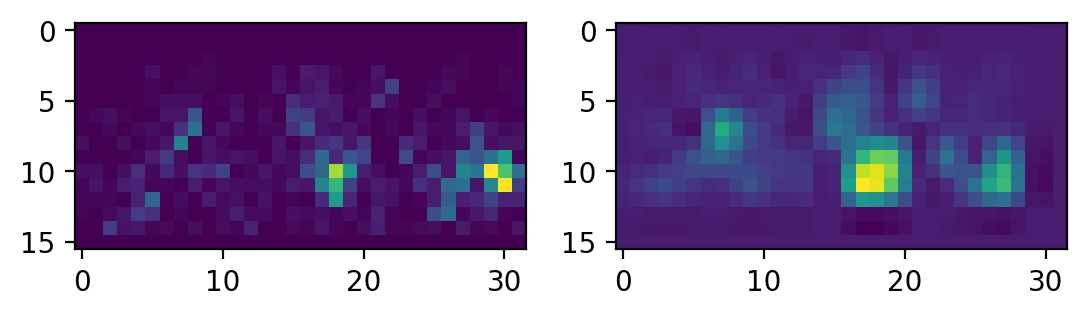

In [85]:
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.imshow(reconstructed)